# 05 — Modeling Fase 1: Content-Based Filtering (TF-IDF)

FASE 1 riset: **menyaring & memberi skor relevansi** venue terhadap preferensi
turis — belum menyusun rute (itu FASE 2 di `06_optimization.ipynb`).

**Komponen** (`src/modeling/cbf.py`):
1. **TF-IDF** — teks `venue_category + description` (Wikipedia ID) → vektor
2. **Cosine similarity** — preferensi turis vs tiap venue → `cbf_score` 0-1
3. **Bayesian weighted rating** (formula IMDB) — popularitas anti-bias venue sepi:
   `WR = (v/(v+m))·R + (m/(v+m))·C` (m = median jumlah review, C = mean rating)
4. **Filter budget** — proxy `CATEGORY_PRICE_LEVEL` per kategori
   (price_level Google kosong 218/219 venue — dideklarasikan sbg estimasi)
5. Output: `satisfaction = w_sim·cbf_score + w_pop·rating_bayesian` →
   dipakai langsung di fitness function GA/PSO (FASE 2)

> Cikal bakal pendekatan ini = prototipe `src/api/recommend.py` (skor hybrid
> TF-IDF + geo + rating + jam untuk API single-query). `cbf.py` menyempurnakan:
> Bayesian rating + filter budget + output satisfaction untuk optimizer.

In [1]:
import os, sys
if hasattr(sys.stdout, 'reconfigure'):  # terminal Windows; Jupyter sudah UTF-8
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')

# Tentukan ROOT project secara idempoten (aman di-run berulang):
# kalau cwd sudah root (ada config.py) pakai cwd, kalau tidak naik 1 level.
_cwd = os.getcwd()
ROOT = _cwd if os.path.exists(os.path.join(_cwd, 'config.py'))        else os.path.abspath(os.path.join(_cwd, '..'))
sys.path.insert(0, ROOT)
sys.path.insert(0, os.path.join(ROOT, 'src', 'modeling'))
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

import config
from cbf import ContentBasedFilter

cbf = ContentBasedFilter()
print(f'Venue ter-load: {len(cbf.df)}')
print(f'Bobot satisfaction: w_sim={config.FITNESS_W_SIM}, w_pop={config.FITNESS_W_POP}')

Venue ter-load: 161
Bobot satisfaction: w_sim=0.6, w_pop=0.4


---
## 1. TF-IDF: dari teks venue jadi vektor

Tiap venue direpresentasikan gabungan `venue_category` + `description`
(Wikipedia). Vocabulary & bobot kata paling khas:

In [2]:
# Ukuran matrix & kata dgn IDF tertinggi (paling khas/jarang)
mat = cbf._mat
vocab = cbf._tfidf.get_feature_names_out()
idf = cbf._tfidf.idf_
print(f'TF-IDF matrix: {mat.shape[0]} venue x {mat.shape[1]} term')

top_idx = np.argsort(idf)[::-1][:15]
low_idx = np.argsort(idf)[:15]
print('\n15 term paling khas (IDF tinggi — pembeda kuat antar venue):')
print(', '.join(vocab[top_idx]))
print('\n15 term paling umum (IDF rendah — muncul di banyak venue):')
print(', '.join(vocab[low_idx]))

TF-IDF matrix: 161 venue x 1029 term

15 term paling khas (IDF tinggi — pembeda kuat antar venue):
"mahabharata.", ±, (7.050.000, 1942., 1945., 1970s, 1999,, 2009, 2017, 2018., 20th-century, 22, 3, 3.500, 30-hectare

15 term paling umum (IDF rendah — muncul di banyak venue):
&, museum, a, with, church, temple, park, history, in, art, the, of, di, yang, indonesian


Venue dengan description: 85/161 (52.8%)
Venue tanpa description tetap ter-vektor-kan dari venue_category-nya.


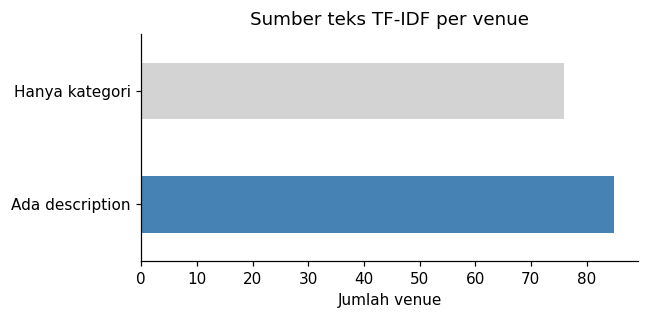

In [3]:
# Coverage description (input utama TF-IDF selain kategori)
n_desc = (cbf.df['description'].notna() & (cbf.df['description'] != '')).sum()
print(f'Venue dengan description: {n_desc}/{len(cbf.df)} ({n_desc/len(cbf.df):.1%})')
print('Venue tanpa description tetap ter-vektor-kan dari venue_category-nya.')

fig, ax = plt.subplots(figsize=(6, 3))
pd.Series({'Ada description': n_desc,
           'Hanya kategori': len(cbf.df) - n_desc}).plot(
    kind='barh', ax=ax, color=['steelblue', 'lightgray'])
ax.set_title('Sumber teks TF-IDF per venue')
ax.set_xlabel('Jumlah venue')
plt.tight_layout()
plt.show()

---
## 2. Bayesian Weighted Rating — anti-bias venue sepi

Masalah rating mentah: venue 5.0★ dari 4 review mengalahkan Monas 4.6★ dari
122rb review. Bayesian rating menarik rating venue ber-review-sedikit ke arah
rata-rata global:

In [4]:
rating = pd.to_numeric(cbf.df['google_rating'], errors='coerce').fillna(0)
count = pd.to_numeric(cbf.df['google_rating_count'], errors='coerce').fillna(0)
m = count.median()
c_mean = rating[rating > 0].mean()
weighted = (count / (count + m)) * rating + (m / (count + m)) * c_mean

cmp = pd.DataFrame({'name': cbf.df['name'], 'rating': rating,
                    'n_review': count.astype(int), 'bayesian': weighted.round(3)})
print(f'm (median review) = {m:.0f} | C (mean rating) = {c_mean:.3f}')
print('\nTop-10 rating MENTAH (bias venue sepi):')
print(cmp.sort_values('rating', ascending=False).head(10).to_string(index=False))
print('\nTop-10 BAYESIAN (populer & bagus beneran):')
print(cmp.sort_values('bayesian', ascending=False).head(10).to_string(index=False))

m (median review) = 1339 | C (mean rating) = 4.652

Top-10 rating MENTAH (bias venue sepi):
                                 name  rating  n_review  bayesian
                Tepekong Jembatan Dua     5.0         7     4.654
                   Vihara Pitakananda     5.0         6     4.654
               Patung Panahan Senayan     5.0         1     4.652
                  Vihara Silaparamita     5.0         8     4.654
           Vihara Prajnaparamita LPUB     5.0        33     4.661
Cemara 6 Galeri - Toeti Heraty Museum     4.9       798     4.745
        Klenteng Hian Thian Siang Tee     4.9        46     4.660
   Antara Gallery of Photo Journalism     4.9       226     4.688
                Gereja Santa Theresia     4.9      4885     4.847
           Gereja Santo Yohanes Bosco     4.8       790     4.707

Top-10 BAYESIAN (populer & bagus beneran):
                                          name  rating  n_review  bayesian
                         Gereja Santa Theresia     4.9      488

---
## 3. Skor relevansi per preferensi turis

Cosine similarity preferensi vs venue + satisfaction final. Tiga profil contoh:

In [5]:
profiles = [
    ('museum sejarah budaya', 'menengah'),
    ('theme park zoo aquarium', 'bebas'),
    ('taman pantai monumen', 'hemat'),
]
for pref, budget in profiles:
    top = cbf.score(pref, budget).head(8)
    print(f'=== Preferensi: "{pref}" | budget: {budget} ===')
    print(top[['name', 'venue_category', 'cbf_score', 'satisfaction']]
          .to_string(index=False))
    print()

=== Preferensi: "museum sejarah budaya" | budget: menengah ===
                                                         name venue_category  cbf_score  satisfaction
                                       Bentara Budaya Jakarta         Museum     0.2792        0.4678
                                                  MOJA Museum         Museum     0.2792        0.4523
                                      Museum Basoeki Abdullah         Museum     0.2792        0.4462
                                        Galeri Indonesia Kaya     Art Museum     0.1551        0.4221
MURI, Museum Rekor-Dunia Indonesia ( Jaya Suprana Institute )         Museum     0.2792        0.4208
                                            Kedaton Jayakarta         Museum     0.2792        0.4103
                                                Galeri Demono         Museum     0.2792        0.4016
                                        Gereja Santa Theresia         Church     0.0000        0.4000

=== Preferensi: "t

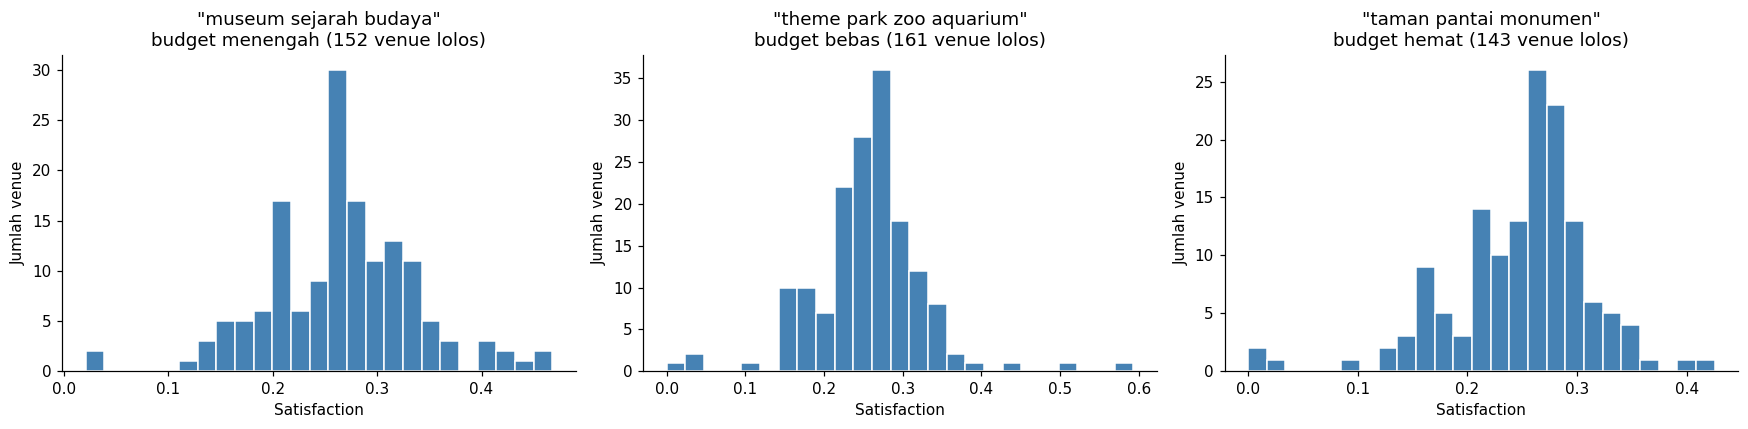

In [6]:
# Distribusi satisfaction per profil (perbandingan visual)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (pref, budget) in zip(axes, profiles):
    s = cbf.score(pref, budget)
    ax.hist(s['satisfaction'], bins=25, color='steelblue', edgecolor='white')
    ax.set_title(f'"{pref[:24]}"\nbudget {budget} ({len(s)} venue lolos)')
    ax.set_xlabel('Satisfaction')
    ax.set_ylabel('Jumlah venue')
plt.tight_layout()
plt.show()

---
## 4. Filter Budget — proxy kategori

`price_level` Google kosong untuk 218/219 venue → pakai estimasi biaya tiket
per kategori (`config.CATEGORY_PRICE_LEVEL`, level 0=gratis..3=mahal).
Deklarasikan sebagai estimasi di laporan.

Distribusi level harga (proxy kategori):
_price
0 gratis               76
1 murah (<50rb)        67
2 sedang (50-150rb)     9
3 mahal (>150rb)        9

Budget "hemat" (level<=1): 143 venue tersedia
Budget "menengah" (level<=2): 152 venue tersedia
Budget "bebas" (level<=3): 161 venue tersedia


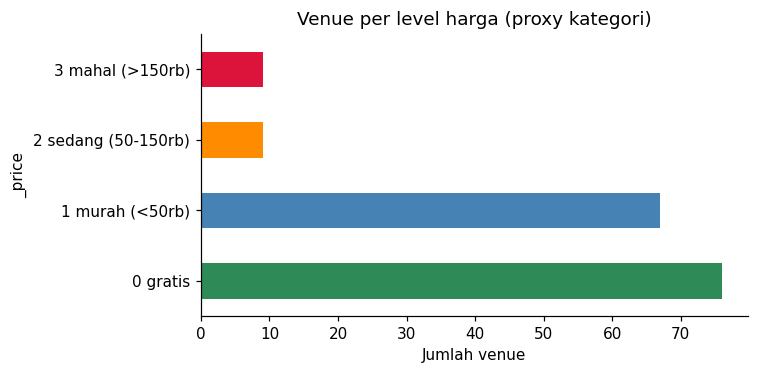

In [7]:
price = cbf.df['_price']
lvl_name = {0: '0 gratis', 1: '1 murah (<50rb)', 2: '2 sedang (50-150rb)', 3: '3 mahal (>150rb)'}
dist = price.map(lvl_name).value_counts().sort_index()
print('Distribusi level harga (proxy kategori):')
print(dist.to_string())
print()
for b, lv in config.BUDGET_LEVELS.items():
    n = (price <= lv).sum()
    print(f'Budget "{b}" (level<={lv}): {n} venue tersedia')

fig, ax = plt.subplots(figsize=(7, 3.5))
dist.plot(kind='barh', ax=ax, color=['seagreen', 'steelblue', 'darkorange', 'crimson'])
ax.set_title('Venue per level harga (proxy kategori)')
ax.set_xlabel('Jumlah venue')
plt.tight_layout()
plt.show()

---
## 5. Output ke FASE 2 — kandidat + satisfaction (seleksi MMR)

`cbf.candidates(n_days, preferensi, budget)` → top-N venue (12 × jumlah hari)
+ dict satisfaction. Inilah yang masuk fitness function GA/PSO di NB 06.

Seleksi memakai **MMR (Maximal Marginal Relevance)**: kandidat dipilih iteratif,
skor = λ·satisfaction − (1−λ)·max_similarity ke kandidat yang sudah terpilih
(λ=0.7 di config). Tanpa ini kandidat didominasi venue kembar — 21 Anjungan
TMII deskripsinya hampir identik, semuanya match query "museum sejarah budaya" —
akibatnya itinerary jenuh satu kompleks dan zona terpaksa dibelah lintas hari.


In [8]:
ids, sat = cbf.candidates(2, 'museum sejarah budaya', 'menengah')
print(f'Kandidat utk itinerary 2 hari: {len(ids)} venue')
print(f'Range satisfaction: {min(sat.values()):.3f} - {max(sat.values()):.3f}')
print()
print('Contoh 5 kandidat teratas:')
for vid in ids[:5]:
    name = cbf.df.loc[cbf.df['venue_id'] == vid, 'name'].values[0]
    print(f'  {sat[vid]:.3f}  {name}')
print()
print('-> Lanjut ke notebooks/06_optimization.ipynb (FASE 2: GA/PSO/Hybrid)')

Kandidat utk itinerary 2 hari: 24 venue
Range satisfaction: 0.276 - 0.468

Contoh 5 kandidat teratas:
  0.468  Bentara Budaya Jakarta
  0.400  Gereja Santa Theresia
  0.348  Bundaran Bank Indonesia (Bundaran Patung Kuda)
  0.347  Masjid Al-Bina
  0.345  Masjid Agung Al-Azhar

-> Lanjut ke notebooks/06_optimization.ipynb (FASE 2: GA/PSO/Hybrid)
